## Supplemental figure 1: Clay density calibration

In [6]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Use given style
plt.style.use("james2026lock.mplstyle")

# define colour hexes
colors = [
    "#710E86",
    "#6EA1FE",
]

# ── Data loading ──────────────────────────────────────────────────────────────
density_data = pd.read_csv("data/clay_density.csv")
# Volume error: 2 ml uncertainty on start and end readings → 4 ml total;
# zero-volume points get a near-zero placeholder to avoid division by zero.
density_data["volume_error (ml)"] = np.where(
    density_data["volume clay (ml)"] == 0, 1e-10, 4
)
# Convert to SI units (m³, kg)
vol = density_data["volume clay (ml)"].values / 1e6
mass = density_data["mass dry clay (g)"].values / 1e3
v_err = density_data["volume_error (ml)"].values / 1e6

In [7]:
def weighted_best_fit(x, y, v_err):
    """
    Weighted linear regression via inverse-variance weighting.

    Parameters
    ----------
    x : array-like  Independent variable (volume).
    y : array-like  Dependent variable (mass).
    v_err : array-like  Uncertainty on x used to form weights.

    Returns
    -------
    slope, intercept, slope_error, r_squared
    """
    w = 1 / v_err**2  # inverse-variance weights

    # Weighted means
    x_bar = np.average(x, weights=w)
    y_bar = np.average(y, weights=w)

    # Weighted covariance and variance
    S_xy = np.sum(w * (x - x_bar) * (y - y_bar))
    S_xx = np.sum(w * (x - x_bar) ** 2)

    slope = S_xy / S_xx
    intercept = y_bar - slope * x_bar

    # Residual standard deviation (2 fitted parameters → n-2 dof)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    sigma_res = np.sqrt(np.sum(w * residuals**2) / (len(x) - 2))

    slope_error = sigma_res / np.sqrt(S_xx)

    # Weighted R²
    ss_res = np.sum(w * residuals**2)
    ss_tot = np.sum(w * (y - y_bar) ** 2)
    r_squared = 1 - ss_res / ss_tot

    return slope, intercept, slope_error, r_squared

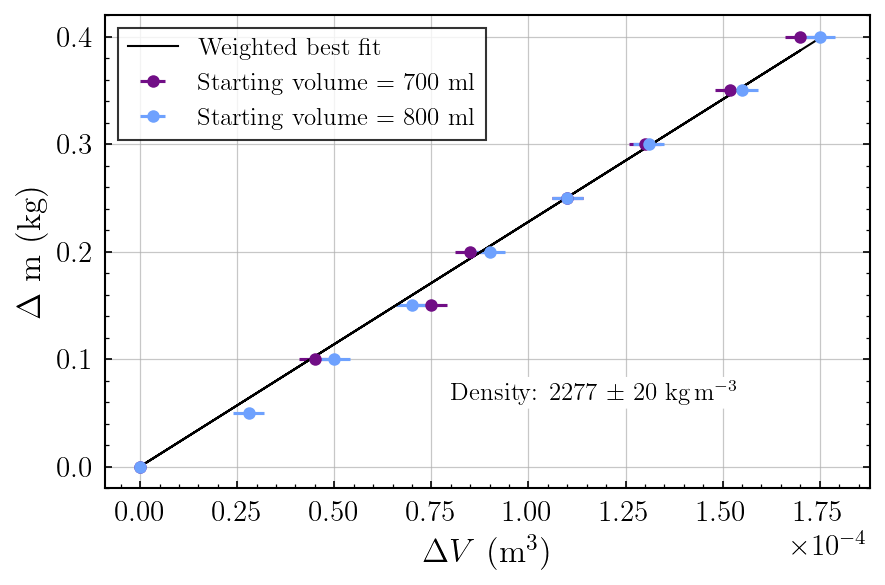

In [9]:
# ── Regression ────────────────────────────────────────────────────────────────

slope, intercept, slope_error, r_squared = weighted_best_fit(vol, mass, v_err)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

# One colour per experimental run
for color, (run_id, group) in zip(colors, density_data.groupby("run")):
    ax.errorbar(
        group["volume clay (ml)"] / 1e6,
        group["mass dry clay (g)"] / 1e3,
        xerr=group["volume_error (ml)"] / 1e6,
        fmt="o",
        capsize=5,
        color=color,
        label=f"Starting volume = {(run_id+6)*100} ml",  # starting vol 700 and 800ml respectively
    )

ax.plot(
    vol, slope * vol + intercept, color="black", linewidth=1, label="Weighted best fit"
)

# Density annotation (axes-fraction coordinates)
ax.text(
    0.8e-4,
    0.08,
    f"Density: {slope:.0f} ± {slope_error:.0f} kg\\,m$^{{-3}}$",
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.1", edgecolor="white", facecolor="white"),
)

ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.set(
    xlabel="$\\Delta V$ (m$^3$)",
    ylabel="$\\Delta$ m (kg)",
)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("figures/sup_figure_1.png", dpi=200)
plt.show()